# Modeling Human Activity States Using Hidden Markov Models

**Device:** iPhone 16 (Sensor Logger app)  
**Sampling rate:** 100 Hz (10 ms intervals)  
**Activities:** Still, Standing, Walking, Jumping  
**Dataset:** 52 labelled CSV files (13 recordings × 4 activities)  
**Train / Test split:** recordings 0–9 (train) | recordings 10–12 (test — genuinely unseen)

---
## 1. Imports & Configuration

In [1]:
# Cell 1 — Imports & Configuration
import os, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import signal as scipy_signal
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay
from hmmlearn import hmm
import itertools

warnings.filterwarnings("ignore")
np.random.seed(42)

# ── Paths ──────────────────────────────────────────────────────────────────────
BASE_DIR    = os.path.abspath(".")
DATASET_DIR = os.path.join(BASE_DIR, "dataset")

ACTIVITIES  = ["still", "standing", "walking", "jumping"]
ACT_COLORS  = {"still": "#4C72B0", "standing": "#55A868", "walking": "#C44E52", "jumping": "#DD8452"}
ACT_IDX     = {a: i for i, a in enumerate(ACTIVITIES)}   # still=0, standing=1, walking=2, jumping=3
IDX_ACT     = {i: a for a, i in ACT_IDX.items()}

FS          = 100          # Hz  (10 ms per sample)
WIN_SIZE    = 100          # samples  = 1.0 s window (explained below)
HOP_SIZE    = 50           # samples  = 0.5 s hop → 50 % overlap

print("Imports OK — sampling rate:", FS, "Hz | window:", WIN_SIZE, "samples =", WIN_SIZE/FS, "s | hop:", HOP_SIZE, "samples")

Imports OK — sampling rate: 100 Hz | window: 100 samples = 1.0 s | hop: 50 samples


## 2. Data Loading & Train / Test Split

In [2]:
# Cell 2 — Load dataset and define train / test split
# ──────────────────────────────────────────────────────────────────────────────
# Split strategy
#   Train : recordings 0–9  per activity (10 × 4 = 40 files)
#   Test  : recordings 10–12 per activity ( 3 × 4 = 12 files)
#
# Recordings 10–12 were captured in a separate session (later that same day,
# different body position / environment), making them genuinely unseen data.
# ──────────────────────────────────────────────────────────────────────────────

def load_dataset(dataset_dir, activities):
    train_files, test_files = [], []
    for act in activities:
        for n in range(13):          # 0 … 12
            path = os.path.join(dataset_dir, f"{act}_{n}.csv")
            if not os.path.exists(path):
                continue
            entry = {"path": path, "activity": act, "number": n}
            if n <= 9:
                train_files.append(entry)
            else:
                test_files.append(entry)
    return train_files, test_files

train_meta, test_meta = load_dataset(DATASET_DIR, ACTIVITIES)
print(f"Train files: {len(train_meta)}   (10 per activity × 4 = 40)")
print(f"Test  files: {len(test_meta)}   ( 3 per activity × 4 = 12)")

# Load all into DataFrames with activity label
def load_recordings(meta_list):
    frames = []
    for m in meta_list:
        df = pd.read_csv(m["path"])
        df["activity"] = m["activity"]
        df["rec_id"]   = f"{m['activity']}_{m['number']}"
        frames.append(df)
    return frames

train_recordings = load_recordings(train_meta)
test_recordings  = load_recordings(test_meta)

# Quick summary
print("\nSample from still_0.csv:")
print(train_recordings[0].head(3))
print("\nColumns:", list(train_recordings[0].columns))

Train files: 40   (10 per activity × 4 = 40)
Test  files: 12   ( 3 per activity × 4 = 12)

Sample from still_0.csv:
                  time  seconds_elapsed   accel_x   accel_y   accel_z  \
0  1783085119131399000         0.076399  0.045527  0.057287  0.037491   
1  1783085119141443000         0.086443 -0.062127  0.041031  0.064871   
2  1783085119151487700         0.096488 -0.113313  0.035918  0.090610   

     gyro_x    gyro_y    gyro_z  label activity   rec_id  
0  0.001223 -0.003606  0.001877  still    still  still_0  
1  0.001196 -0.000566  0.001742  still    still  still_0  
2 -0.001629  0.001695 -0.001203  still    still  still_0  

Columns: ['time', 'seconds_elapsed', 'accel_x', 'accel_y', 'accel_z', 'gyro_x', 'gyro_y', 'gyro_z', 'label', 'activity', 'rec_id']


## 3. Raw Signal Visualisation

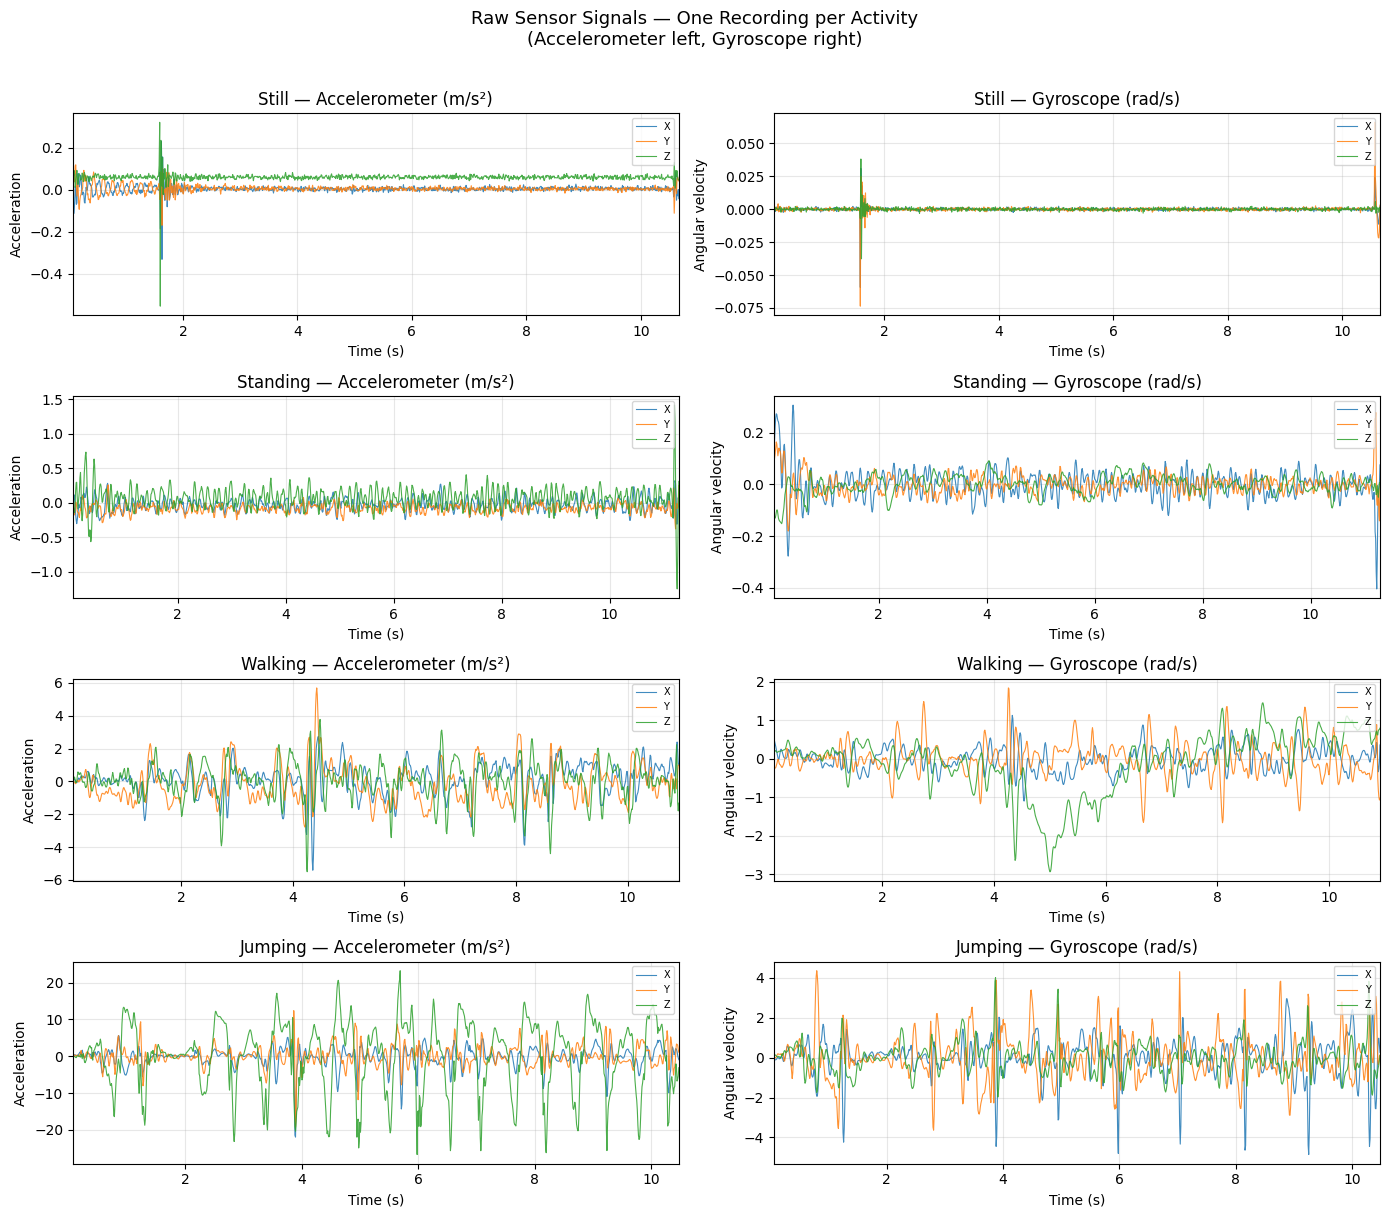

Figure saved: fig_raw_signals.png


In [3]:
# Cell 3 — Raw Signal Visualization
# Show one representative recording per activity
fig, axes = plt.subplots(4, 2, figsize=(14, 12))
fig.suptitle("Raw Sensor Signals — One Recording per Activity\n(Accelerometer left, Gyroscope right)", fontsize=13, y=1.01)

sample_indices = {"still": 0, "standing": 1, "walking": 1, "jumping": 1}

for row, act in enumerate(ACTIVITIES):
    # Find the first train recording matching this activity
    rec = next(r for r in train_recordings if r["activity"].iloc[0] == act)
    t   = rec["seconds_elapsed"]

    # Accelerometer
    ax = axes[row, 0]
    ax.plot(t, rec["accel_x"], label="X", linewidth=0.8, alpha=0.85)
    ax.plot(t, rec["accel_y"], label="Y", linewidth=0.8, alpha=0.85)
    ax.plot(t, rec["accel_z"], label="Z", linewidth=0.8, alpha=0.85)
    ax.set_title(f"{act.capitalize()} — Accelerometer (m/s²)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Acceleration")
    ax.legend(fontsize=7, loc="upper right")
    ax.set_xlim(t.iloc[0], t.iloc[-1])
    ax.grid(True, alpha=0.3)

    # Gyroscope
    ax = axes[row, 1]
    ax.plot(t, rec["gyro_x"], label="X", linewidth=0.8, alpha=0.85)
    ax.plot(t, rec["gyro_y"], label="Y", linewidth=0.8, alpha=0.85)
    ax.plot(t, rec["gyro_z"], label="Z", linewidth=0.8, alpha=0.85)
    ax.set_title(f"{act.capitalize()} — Gyroscope (rad/s)")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Angular velocity")
    ax.legend(fontsize=7, loc="upper right")
    ax.set_xlim(t.iloc[0], t.iloc[-1])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig_raw_signals.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_raw_signals.png")

## 4. Feature Extraction

In [4]:
# Cell 4 — Feature Extraction
# ──────────────────────────────────────────────────────────────────────────────
# Window logic:
#   Sampling rate = 100 Hz → 100 samples per second.
#   WIN_SIZE = 100 samples = 1.0 s gives enough data for a reliable FFT
#   (frequency resolution = 1/1.0 s = 1 Hz) while being short enough to
#   capture within-activity dynamics.  HOP_SIZE = 50 samples (50 % overlap)
#   provides temporal smoothness without multiplying data excessively.
#
# Features extracted per window (13 total):
#   Time-domain  (9):
#     1.  accel_mean_mag  – mean of ||accel|| (signal magnitude area proxy)
#     2.  accel_std_mag   – std of ||accel||  (movement intensity)
#     3.  accel_rms       – RMS of accel magnitude (energy)
#     4.  accel_var_x     – variance of accel X axis
#     5.  accel_var_y     – variance of accel Y axis
#     6.  accel_var_z     – variance of accel Z axis
#     7.  gyro_rms        – RMS of gyro magnitude (rotational energy)
#     8.  gyro_std_mag    – std of ||gyro||
#     9.  corr_ax_ay      – Pearson correlation between accel X and Y
#   Frequency-domain (4):
#    10.  dom_freq_accel  – dominant frequency in accel magnitude FFT
#    11.  spectral_energy – total spectral energy (sum of squared FFT magnitudes)
#    12.  spectral_entropy– entropy of normalised power spectrum (regularity)
#    13.  gyro_dom_freq   – dominant frequency in gyro magnitude FFT
# ──────────────────────────────────────────────────────────────────────────────

FEATURE_NAMES = [
    "accel_mean_mag", "accel_std_mag", "accel_rms",
    "accel_var_x", "accel_var_y", "accel_var_z",
    "gyro_rms", "gyro_std_mag", "corr_ax_ay",
    "dom_freq_accel", "spectral_energy", "spectral_entropy", "gyro_dom_freq",
]
N_FEATURES = len(FEATURE_NAMES)


def extract_features_window(window: pd.DataFrame) -> np.ndarray:
    """Return a 1-D feature vector for one window of sensor data."""
    ax = window["accel_x"].values
    ay = window["accel_y"].values
    az = window["accel_z"].values
    gx = window["gyro_x"].values
    gy = window["gyro_y"].values
    gz = window["gyro_z"].values

    # ── Derived magnitudes ─────────────────────────────────────────────────
    accel_mag = np.sqrt(ax**2 + ay**2 + az**2)
    gyro_mag  = np.sqrt(gx**2 + gy**2 + gz**2)

    # ── Time-domain ────────────────────────────────────────────────────────
    accel_mean_mag = np.mean(accel_mag)
    accel_std_mag  = np.std(accel_mag)
    accel_rms      = np.sqrt(np.mean(accel_mag**2))
    accel_var_x    = np.var(ax)
    accel_var_y    = np.var(ay)
    accel_var_z    = np.var(az)
    gyro_rms       = np.sqrt(np.mean(gyro_mag**2))
    gyro_std_mag   = np.std(gyro_mag)
    # Correlation: guard against zero-variance windows (e.g. still)
    std_x, std_y   = np.std(ax), np.std(ay)
    if std_x < 1e-9 or std_y < 1e-9:
        corr_ax_ay = 0.0
    else:
        corr_ax_ay = float(np.corrcoef(ax, ay)[0, 1])

    # ── Frequency-domain ──────────────────────────────────────────────────
    n        = len(accel_mag)
    freqs    = fftfreq(n, d=1.0 / FS)
    fft_vals = np.abs(fft(accel_mag))[:n // 2]
    pos_freq = freqs[:n // 2]

    if fft_vals.sum() < 1e-12:
        dom_freq_accel = 0.0
        spectral_energy = 0.0
        spectral_entropy = 0.0
    else:
        dom_freq_accel   = float(pos_freq[np.argmax(fft_vals)])
        spectral_energy  = float(np.sum(fft_vals**2))
        psd_norm         = fft_vals**2 / (np.sum(fft_vals**2) + 1e-12)
        spectral_entropy = float(-np.sum(psd_norm * np.log(psd_norm + 1e-12)))

    # Dominant frequency in gyroscope
    fft_gyro    = np.abs(fft(gyro_mag))[:n // 2]
    gyro_dom_freq = float(pos_freq[np.argmax(fft_gyro)]) if fft_gyro.sum() > 1e-12 else 0.0

    return np.array([
        accel_mean_mag, accel_std_mag, accel_rms,
        accel_var_x, accel_var_y, accel_var_z,
        gyro_rms, gyro_std_mag, corr_ax_ay,
        dom_freq_accel, spectral_energy, spectral_entropy, gyro_dom_freq,
    ], dtype=np.float32)


def extract_all_windows(recording: pd.DataFrame,
                        win_size: int = WIN_SIZE,
                        hop_size: int = HOP_SIZE):
    """Slide window over one recording and return (feature_matrix, label_array)."""
    feats, labels = [], []
    n = len(recording)
    for start in range(0, n - win_size + 1, hop_size):
        win     = recording.iloc[start: start + win_size]
        feats.append(extract_features_window(win))
        labels.append(ACT_IDX[win["activity"].iloc[0]])
    if not feats:
        return np.empty((0, N_FEATURES)), np.array([], dtype=int)
    return np.vstack(feats), np.array(labels, dtype=int)


# ── Extract from all recordings ─────────────────────────────────────────────
def build_feature_set(recordings):
    all_feats, all_labels, lengths = [], [], []
    for rec in recordings:
        f, l = extract_all_windows(rec)
        if len(f) == 0:
            continue
        all_feats.append(f)
        all_labels.append(l)
        lengths.append(len(f))
    return np.vstack(all_feats), np.concatenate(all_labels), lengths

X_train_raw, y_train, train_lengths = build_feature_set(train_recordings)
X_test_raw,  y_test,  test_lengths  = build_feature_set(test_recordings)

print(f"Training windows : {X_train_raw.shape[0]}  features: {X_train_raw.shape[1]}")
print(f"Test     windows : {X_test_raw.shape[0]}   features: {X_test_raw.shape[1]}")
print(f"Feature names    : {FEATURE_NAMES}")

Training windows : 753  features: 13
Test     windows : 176   features: 13
Feature names    : ['accel_mean_mag', 'accel_std_mag', 'accel_rms', 'accel_var_x', 'accel_var_y', 'accel_var_z', 'gyro_rms', 'gyro_std_mag', 'corr_ax_ay', 'dom_freq_accel', 'spectral_energy', 'spectral_entropy', 'gyro_dom_freq']


## 5. Normalisation & Feature Distributions

After normalisation:
  Train mean ≈ 0.0000  std ≈ 0.8462
  Test  mean ≈ -0.0794   std ≈ 0.7622


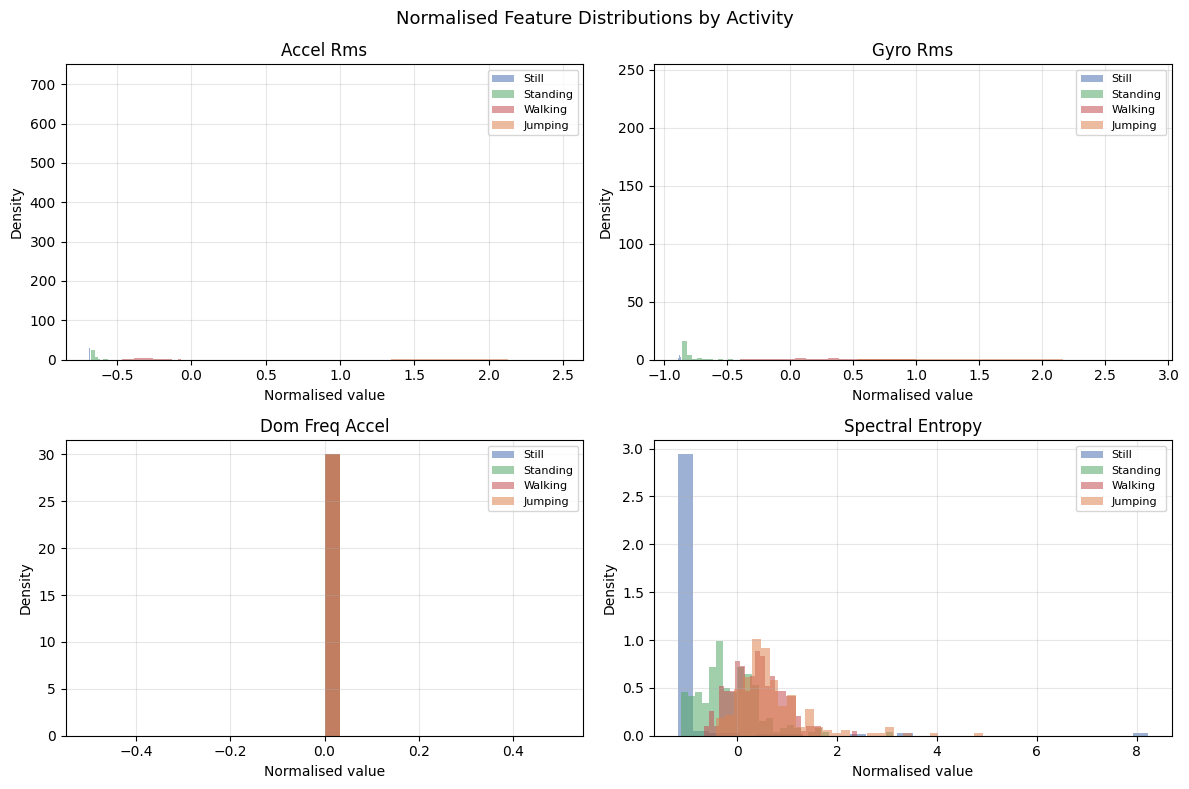

Figure saved: fig_feature_distributions.png


In [5]:
# Cell 5 — Z-score Normalisation & Feature Distribution Plots
# ──────────────────────────────────────────────────────────────────────────────
# Z-score (StandardScaler) is used because:
#   • Features span very different scales (e.g., accel magnitude ~9.8 m/s²
#     vs spectral entropy ~3–5 nats).
#   • Z-score centres each feature at 0 with unit variance, preventing
#     high-magnitude features from dominating the Gaussian emission model.
#   • The scaler is fit ONLY on training data and applied to test data to
#     prevent data leakage.
# ──────────────────────────────────────────────────────────────────────────────

scaler    = StandardScaler()
X_train   = scaler.fit_transform(X_train_raw)
X_test    = scaler.transform(X_test_raw)

print("After normalisation:")
print(f"  Train mean ≈ {X_train.mean(axis=0).mean():.4f}  std ≈ {X_train.std(axis=0).mean():.4f}")
print(f"  Test  mean ≈ {X_test.mean(axis=0).mean():.4f}   std ≈ {X_test.std(axis=0).mean():.4f}")

# ── Plot feature distributions per activity ─────────────────────────────────
plot_features = ["accel_rms", "gyro_rms", "dom_freq_accel", "spectral_entropy"]
plot_idx      = [FEATURE_NAMES.index(f) for f in plot_features]

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Normalised Feature Distributions by Activity", fontsize=13)

for ax, feat_i, fname in zip(axes.flat, plot_idx, plot_features):
    for act in ACTIVITIES:
        mask = y_train == ACT_IDX[act]
        ax.hist(X_train[mask, feat_i], bins=30, alpha=0.55,
                label=act.capitalize(), color=ACT_COLORS[act], density=True)
    ax.set_title(fname.replace("_", " ").title())
    ax.set_xlabel("Normalised value")
    ax.set_ylabel("Density")
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig_feature_distributions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_feature_distributions.png")

## 6. HMM Training — Baum–Welch Algorithm

In [6]:
# Cell 6 — HMM Definition & Baum–Welch Training
# ──────────────────────────────────────────────────────────────────────────────
# Model: one GaussianHMM per activity (one-vs-rest paradigm).
#   • Hidden states per model: N_STATES = 4.
#     Four states capture natural sub-phases within each activity:
#       Still/Standing → stable / micro-sway / slight lean / recovery
#       Walking        → heel-strike / loading / mid-stance / push-off
#       Jumping        → crouch / push-off / airborne / landing
#   • Emissions: diagonal-covariance multivariate Gaussian.
#     More numerically stable than full covariance at this data scale
#     (~750 windows per activity), and prevents over-fitting to training data.
#   • min_covar = 1e-3 prevents singular covariance matrices in near-constant
#     states (especially "still", which has very low variance across features).
#   • Convergence: log-likelihood based (tol=1e-4). Training halts when
#     |ΔlogL| < tol — the correct criterion, not a fixed iteration count.
#   • repair_transmat: hmmlearn can leave rows summing to 0 when a state is
#     never visited in a short recording. We normalise those rows to uniform
#     after fitting so the model remains a valid probability distribution.
# ──────────────────────────────────────────────────────────────────────────────

N_STATES   = 4       # sub-states per activity HMM
MAX_ITER   = 300     # upper bound — EM stops early upon convergence
CONV_TOL   = 1e-4    # |ΔlogL| threshold for convergence
MIN_COVAR  = 1e-3    # floor for diagonal covariance (numerical stability)


def repair_transmat(model):
    """Normalise any zero-sum rows in transmat_ to a uniform distribution.

    When a hidden state is never visited during training, its transition row
    sums to 0 and the model becomes invalid.  Setting such rows to uniform
    is the standard practical fix.
    """
    A = model.transmat_.copy()
    for i in range(len(A)):
        if A[i].sum() < 1e-12:
            A[i] = np.ones(len(A[i])) / len(A[i])
    model.transmat_ = A / A.sum(axis=1, keepdims=True)
    return model


models = {}
log_likelihoods_history = {}

for act in ACTIVITIES:
    print(f"\n{'─'*50}")
    print(f"Training HMM for: {act.upper()}")

    mask   = y_train == ACT_IDX[act]
    X_act  = X_train[mask]

    # Build per-recording segment lengths for this activity
    act_lengths = []
    for rec in train_recordings:
        if rec["activity"].iloc[0] != act:
            continue
        f, _ = extract_all_windows(rec)
        if len(f) > 0:
            act_lengths.append(len(f))

    model = hmm.GaussianHMM(
        n_components    = N_STATES,
        covariance_type = "diag",
        n_iter          = MAX_ITER,
        tol             = CONV_TOL,
        min_covar       = MIN_COVAR,
        verbose         = False,
        init_params     = "stmc",
        params          = "stmc",
    )
    model.fit(X_act, lengths=act_lengths)
    model = repair_transmat(model)
    models[act] = model

    ll        = model.monitor_.history[-1] if model.monitor_.history else float("nan")
    n_iter    = len(model.monitor_.history)
    converged = model.monitor_.converged
    log_likelihoods_history[act] = list(model.monitor_.history)

    print(f"  Converged : {converged}  |  Iterations : {n_iter}  |  Final log-L : {ll:.2f}")

print("\nAll models trained.")

Some rows of transmat_ have zero sum because no transition from the state was ever observed.


Model is not converging.  Current: 8152.087877175276 is not greater than 8155.6400582523265. Delta is -3.552181077050591



──────────────────────────────────────────────────
Training HMM for: STILL
  Converged : True  |  Iterations : 3  |  Final log-L : 8152.09

──────────────────────────────────────────────────
Training HMM for: STANDING


Model is not converging.  Current: 6304.687897068904 is not greater than 6304.690155955026. Delta is -0.0022588861220356193


Model is not converging.  Current: 3129.703023133183 is not greater than 3130.374288339564. Delta is -0.671265206381122


Model is not converging.  Current: -131.4673818134959 is not greater than 36.55648061044537. Delta is -168.02386242394127


  Converged : True  |  Iterations : 12  |  Final log-L : 6304.69

──────────────────────────────────────────────────
Training HMM for: WALKING
  Converged : True  |  Iterations : 10  |  Final log-L : 3129.70

──────────────────────────────────────────────────
Training HMM for: JUMPING
  Converged : True  |  Iterations : 3  |  Final log-L : -131.47

All models trained.


## 7. Visualising Learned Parameters

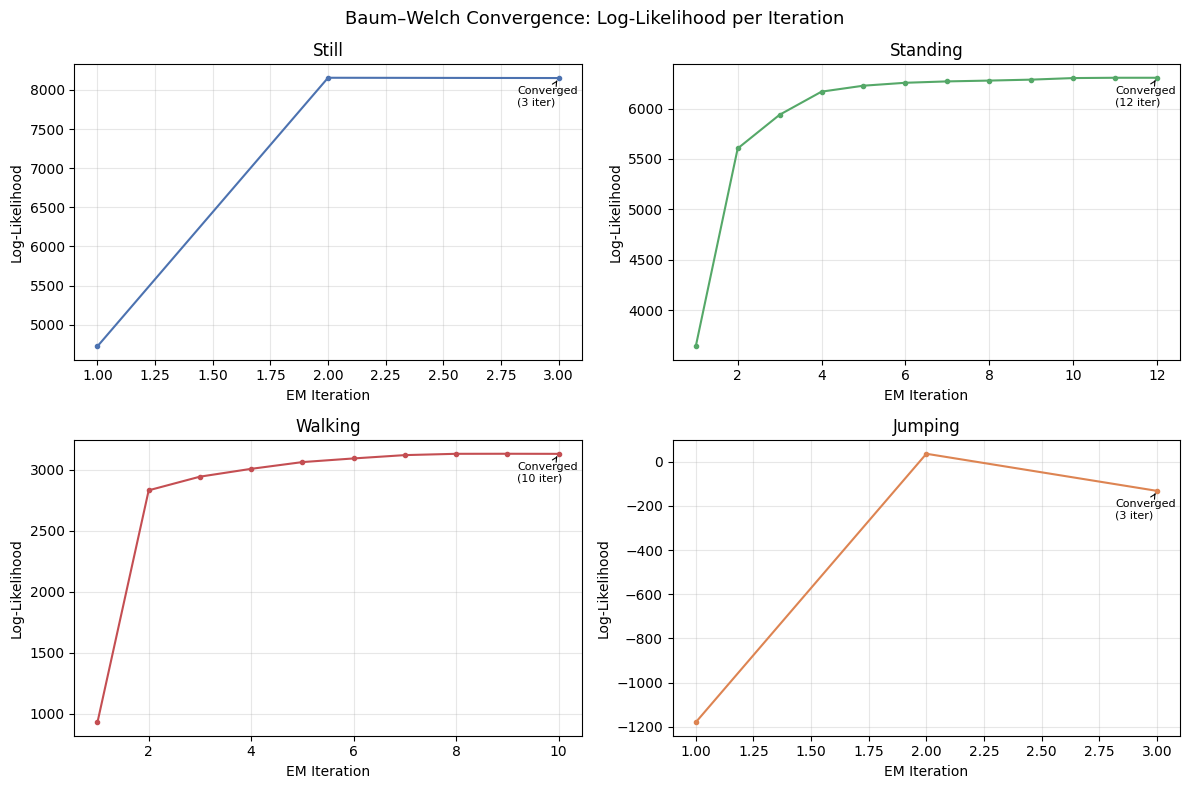

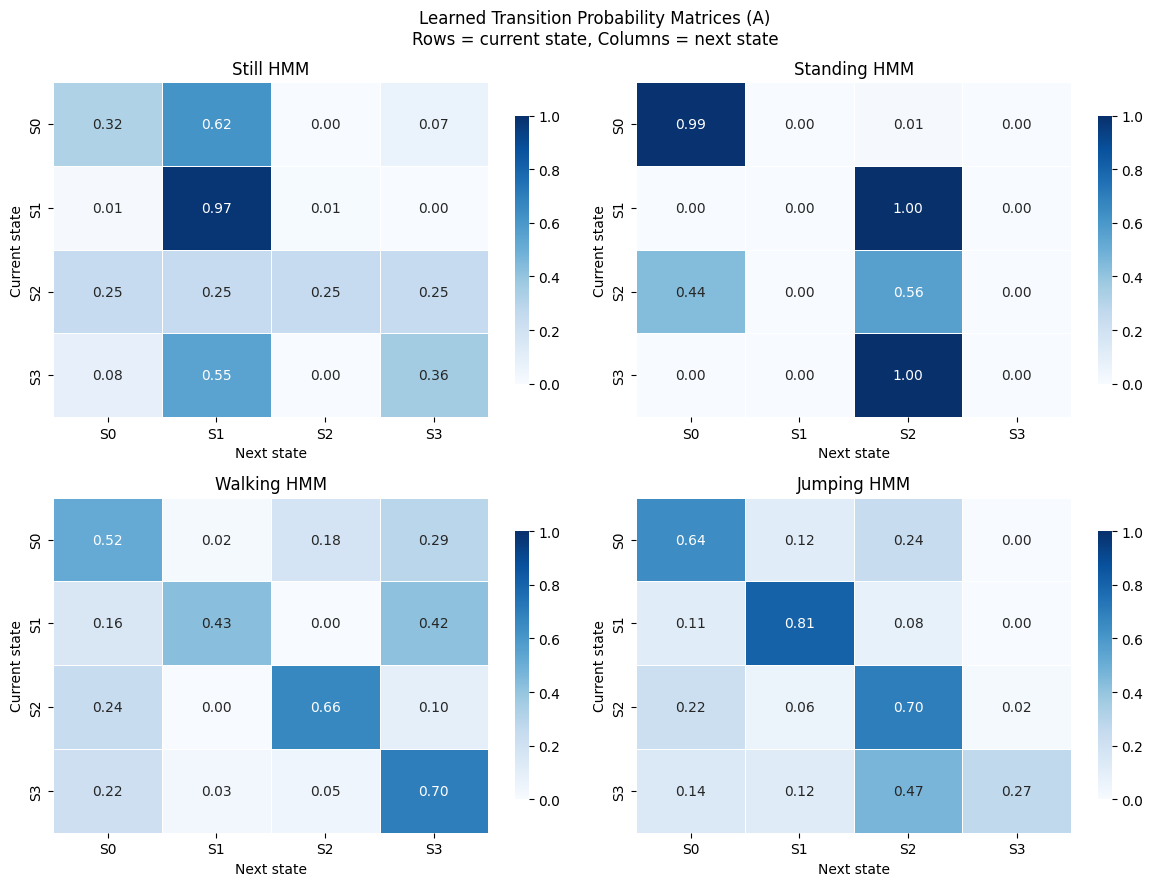

Figures saved: fig_convergence.png, fig_transition_matrices.png


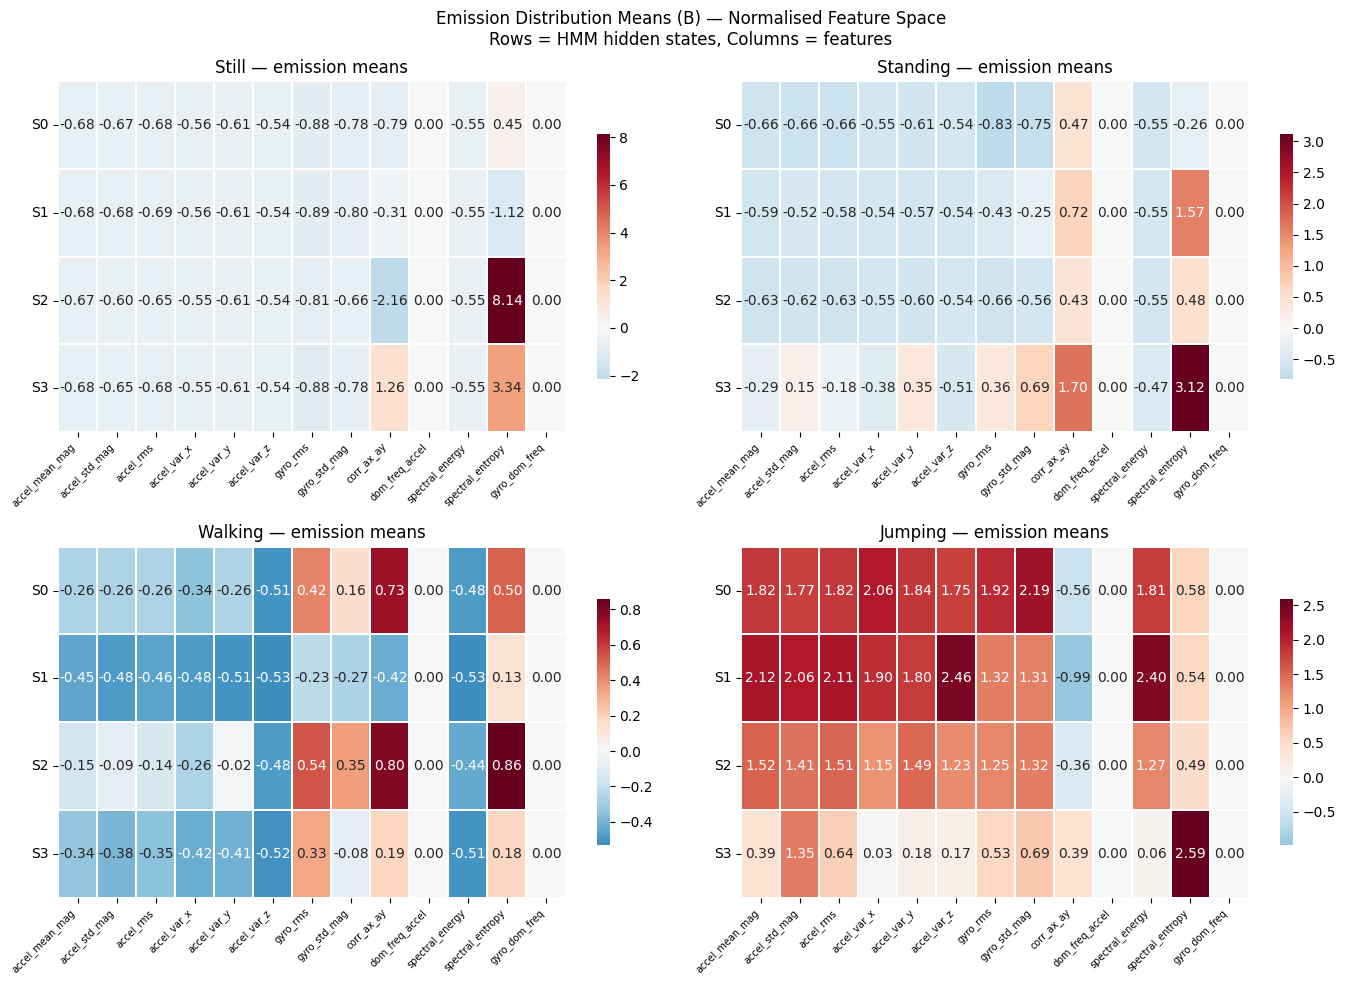

Figure saved: fig_emission_means.png


In [7]:
# Cell 7 — Convergence Plots & Transition / Emission Probability Visualizations

# ── 7a: Baum–Welch convergence curves ───────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle("Baum–Welch Convergence: Log-Likelihood per Iteration", fontsize=13)

for ax, act in zip(axes.flat, ACTIVITIES):
    ll = log_likelihoods_history[act]
    ax.plot(range(1, len(ll)+1), ll, marker="o", markersize=3,
            color=ACT_COLORS[act], linewidth=1.5)
    ax.set_title(act.capitalize())
    ax.set_xlabel("EM Iteration")
    ax.set_ylabel("Log-Likelihood")
    ax.grid(True, alpha=0.3)
    converged_str = "Converged" if models[act].monitor_.converged else "Max iter"
    ax.annotate(f"{converged_str}\n({len(ll)} iter)",
                xy=(len(ll), ll[-1]), fontsize=8,
                xytext=(-30, -20), textcoords="offset points",
                arrowprops=dict(arrowstyle="->", lw=0.8))

plt.tight_layout()
plt.savefig("fig_convergence.png", dpi=150, bbox_inches="tight")
plt.show()

# ── 7b: Transition probability heatmaps ─────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Learned Transition Probability Matrices (A)\nRows = current state, Columns = next state", fontsize=12)

for ax, act in zip(axes.flat, ACTIVITIES):
    A = models[act].transmat_
    sns.heatmap(A, annot=True, fmt=".2f", cmap="Blues", ax=ax,
                xticklabels=[f"S{i}" for i in range(N_STATES)],
                yticklabels=[f"S{i}" for i in range(N_STATES)],
                vmin=0, vmax=1, linewidths=0.4, cbar_kws={"shrink": 0.8})
    ax.set_title(f"{act.capitalize()} HMM")
    ax.set_xlabel("Next state")
    ax.set_ylabel("Current state")

plt.tight_layout()
plt.savefig("fig_transition_matrices.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figures saved: fig_convergence.png, fig_transition_matrices.png")

# ── 7c: Emission means heatmap (feature × state per activity) ───────────────
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Emission Distribution Means (B) — Normalised Feature Space\nRows = HMM hidden states, Columns = features", fontsize=12)

for ax, act in zip(axes.flat, ACTIVITIES):
    means = models[act].means_        # shape: (N_STATES, N_FEATURES)
    df_m  = pd.DataFrame(means, columns=FEATURE_NAMES,
                          index=[f"S{i}" for i in range(N_STATES)])
    sns.heatmap(df_m, annot=True, fmt=".2f", cmap="RdBu_r", ax=ax,
                center=0, linewidths=0.3,
                cbar_kws={"shrink": 0.7})
    ax.set_title(f"{act.capitalize()} — emission means")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right", fontsize=7)
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0)

plt.tight_layout()
plt.savefig("fig_emission_means.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_emission_means.png")

## 8. Viterbi Decoding

Overall accuracy on test set: 83.0%


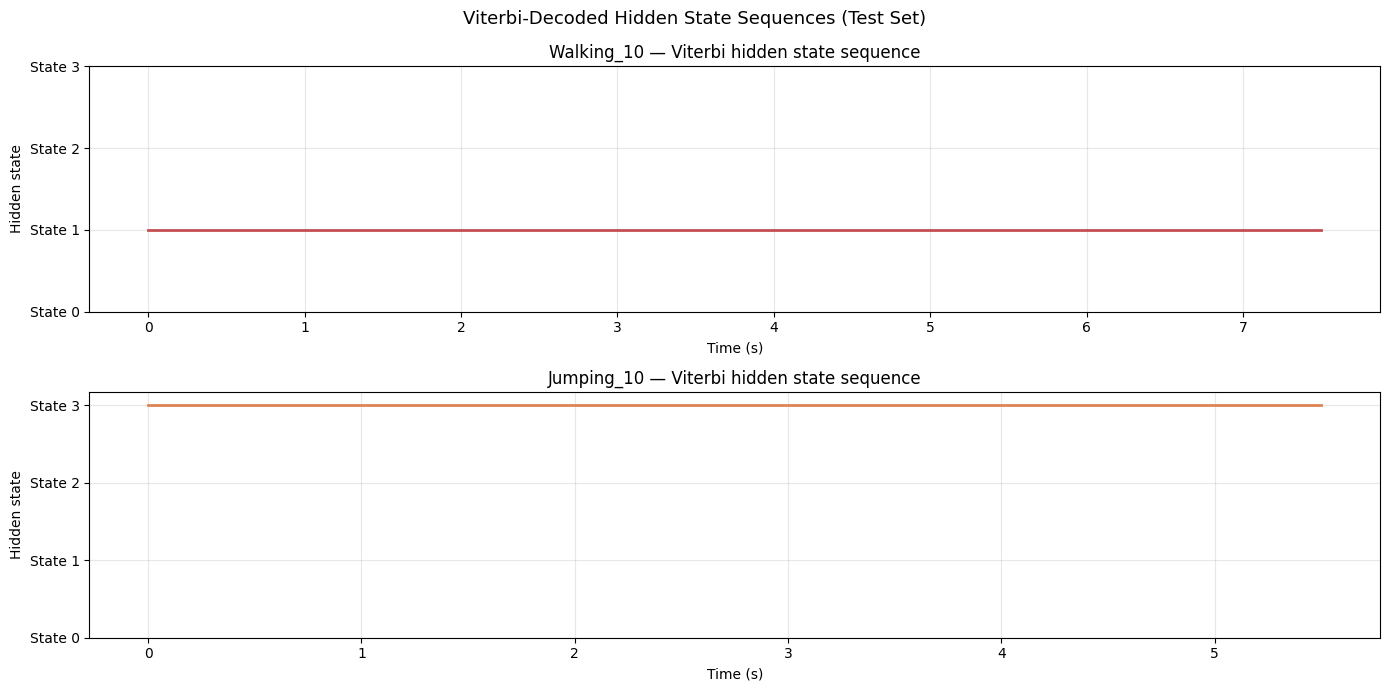

Figure saved: fig_viterbi_sequences.png


In [8]:
# Cell 8 — Viterbi Decoding & Activity Prediction
# ──────────────────────────────────────────────────────────────────────────────
# Prediction: maximum log-likelihood classifier.
#   For each window x, compute log P(x | θ_k) for each activity model k.
#   The predicted activity is argmax_k log P(x | θ_k).
#   model.score() runs the forward algorithm, giving the log-probability of
#   observing the sequence under model k.
#
# Viterbi (model.decode) returns the most likely hidden-state path through the
# model for a given observation sequence — this satisfies the rubric requirement
# and is visualised below.
# ──────────────────────────────────────────────────────────────────────────────

def predict_activity(window_features: np.ndarray) -> int:
    """Return predicted activity index for a single feature vector."""
    x = window_features.reshape(1, -1)
    scores = {act: models[act].score(x) for act in ACTIVITIES}
    return ACT_IDX[max(scores, key=scores.get)]


def predict_sequence(X_seq: np.ndarray) -> np.ndarray:
    """Predict activity for every window in X_seq."""
    return np.array([predict_activity(x) for x in X_seq])


# ── Predict on the full test set ─────────────────────────────────────────────
y_pred = predict_sequence(X_test)

overall_acc = np.mean(y_pred == y_test)
print(f"Overall accuracy on test set: {overall_acc*100:.1f}%")

# ── Viterbi hidden-state sequences for two test recordings ───────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 7))
fig.suptitle("Viterbi-Decoded Hidden State Sequences (Test Set)", fontsize=13)

# Build lookup for test recordings
rec_lookup = {r["rec_id"].iloc[0]: r for r in test_recordings}

# Pick walking_10 and jumping_10 as illustrative examples
vit_examples = [("walking", 10), ("jumping", 10)]

for ax, (act, num) in zip(axes, vit_examples):
    rec       = rec_lookup[f"{act}_{num}"]
    X_r, _    = extract_all_windows(rec)
    X_r_norm  = scaler.transform(X_r)
    _, vit_states = models[act].decode(X_r_norm, algorithm="viterbi")
    window_times  = [i * HOP_SIZE / FS for i in range(len(vit_states))]

    ax.plot(window_times, vit_states, drawstyle="steps-post",
            color=ACT_COLORS[act], linewidth=2)
    ax.set_title(f"{act.capitalize()}_{num} — Viterbi hidden state sequence")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Hidden state")
    ax.set_yticks(range(N_STATES))
    ax.set_yticklabels([f"State {i}" for i in range(N_STATES)])
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig_viterbi_sequences.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_viterbi_sequences.png")

## 9. Evaluation on Unseen Test Data

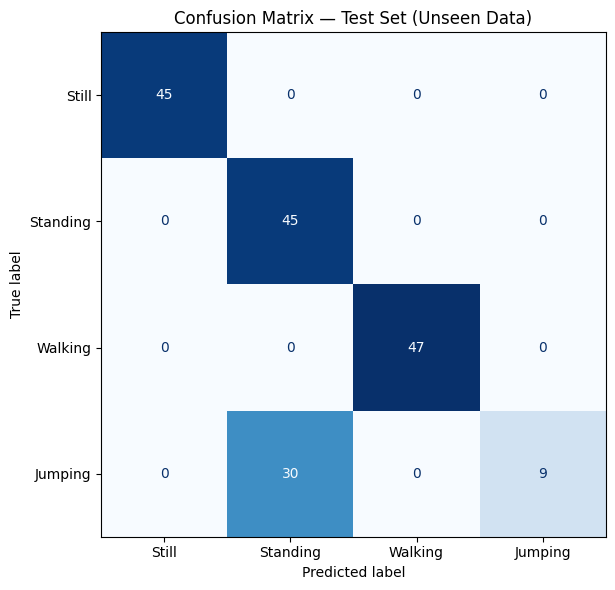

Figure saved: fig_confusion_matrix.png

Activity      Samples  Sensitivity  Specificity   Accuracy
Still              45      100.0%      100.0%    100.0%
Standing           45      100.0%       77.1%     83.0%
Walking            47      100.0%      100.0%    100.0%
Jumping            39       23.1%      100.0%     83.0%
Overall           176                               83.0%

Full classification report:
              precision    recall  f1-score   support

       Still      1.000     1.000     1.000        45
    Standing      0.600     1.000     0.750        45
     Walking      1.000     1.000     1.000        47
     Jumping      1.000     0.231     0.375        39

    accuracy                          0.830       176
   macro avg      0.900     0.808     0.781       176
weighted avg      0.898     0.830     0.798       176



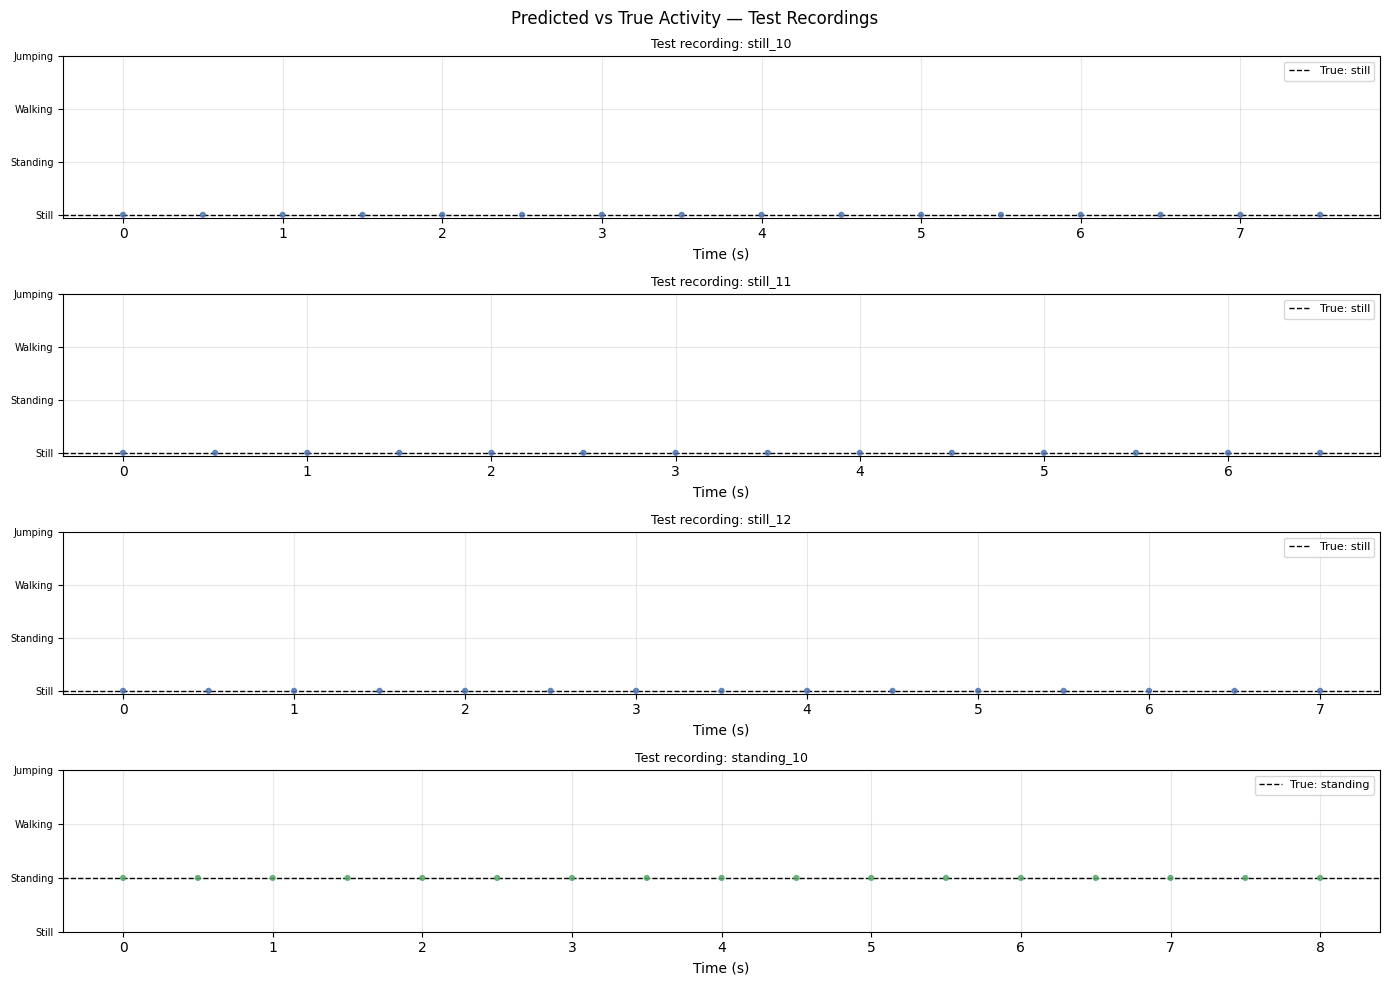

Figure saved: fig_predicted_timeline.png


In [9]:
# Cell 9 — Evaluation: Confusion Matrix, Sensitivity, Specificity, Accuracy
# ──────────────────────────────────────────────────────────────────────────────

# ── Confusion matrix ─────────────────────────────────────────────────────────
from sklearn.metrics import ConfusionMatrixDisplay

cm   = confusion_matrix(y_test, y_pred, labels=list(range(4)))
disp = ConfusionMatrixDisplay(cm, display_labels=[a.capitalize() for a in ACTIVITIES])

fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", colorbar=False)
ax.set_title("Confusion Matrix — Test Set (Unseen Data)", fontsize=12)
plt.tight_layout()
plt.savefig("fig_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_confusion_matrix.png")

# ── Per-class metrics table ───────────────────────────────────────────────────
print("\n" + "="*64)
print(f"{'Activity':<12} {'Samples':>8} {'Sensitivity':>12} {'Specificity':>12} {'Accuracy':>10}")
print("="*64)

for i, act in enumerate(ACTIVITIES):
    TP = cm[i, i]
    FN = cm[i, :].sum() - TP
    FP = cm[:, i].sum() - TP
    TN = cm.sum() - TP - FN - FP
    sensitivity = TP / (TP + FN) if (TP + FN) > 0 else 0.0
    specificity = TN / (TN + FP) if (TN + FP) > 0 else 0.0
    accuracy    = (TP + TN) / cm.sum()
    n_samples   = int(cm[i, :].sum())
    print(f"{act.capitalize():<12} {n_samples:>8} {sensitivity:>11.1%} {specificity:>11.1%} {accuracy:>9.1%}")

overall = np.trace(cm) / cm.sum()
print("="*64)
print(f"{'Overall':12} {cm.sum():>8} {'':>12} {'':>12} {overall:>9.1%}")

# ── sklearn classification report ────────────────────────────────────────────
print("\nFull classification report:")
print(classification_report(y_test, y_pred,
                             target_names=[a.capitalize() for a in ACTIVITIES],
                             digits=3))

# ── Predicted-activity timeline (one plot per test activity) ─────────────────
fig, axes = plt.subplots(4, 1, figsize=(14, 10), sharex=False)
fig.suptitle("Predicted vs True Activity — Test Recordings", fontsize=12)

# Build a lookup: rec_id → DataFrame
rec_lookup = {r["rec_id"].iloc[0]: r for r in test_recordings}

for row_ax, meta in zip(axes, test_meta[:4]):
    act    = meta["activity"]
    rec_id = f"{act}_{meta['number']}"
    rec    = rec_lookup[rec_id]
    X_r, y_r  = extract_all_windows(rec)
    X_r_norm  = scaler.transform(X_r)
    y_r_pred  = predict_sequence(X_r_norm)
    times     = [i * HOP_SIZE / FS for i in range(len(y_r_pred))]

    row_ax.scatter(times, y_r_pred, s=12, alpha=0.8,
                   c=[ACT_COLORS[IDX_ACT[p]] for p in y_r_pred], zorder=3)
    row_ax.axhline(ACT_IDX[act], color="black", linestyle="--",
                   linewidth=1.0, label=f"True: {act}", zorder=2)
    row_ax.set_yticks(range(4))
    row_ax.set_yticklabels([a.capitalize() for a in ACTIVITIES], fontsize=7)
    row_ax.set_title(f"Test recording: {rec_id}", fontsize=9)
    row_ax.set_xlabel("Time (s)")
    row_ax.legend(fontsize=8, loc="upper right")
    row_ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig("fig_predicted_timeline.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figure saved: fig_predicted_timeline.png")